# Prophet Model — Demand Forecasting
### Makerere University Cafeteria Dataset

**Goal:** Forecast future portions sold per cafeteria and meal using Facebook Prophet.  
Prophet detects weekly and yearly seasonal patterns automatically from historical data.

**Date range:** February 2024 — December 2025 (700 days)

## Step 1 — Install and Import

In [1]:
# install prophet if not already installed
# !pip install prophet --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

print('Libraries loaded.')

Libraries loaded.


## Step 2 — Load the Data

In [2]:
df = pd.read_csv('makerere_Cafeteria_synthetic.csv')

money_cols = ['Price_UGX', 'Revenue_UGX', 'Ingredient_Cost_UGX', 'Waste_Cost_UGX', 'Gross_Profit_UGX']
for col in money_cols:
    df[col] = df[col].astype(str).str.replace(',', '').astype(float)

df['Date'] = pd.to_datetime(df['Date'])

print(df.shape)
df.head()

(58800, 30)


,Cafeteria_ID,Cafeteria_Name,Date,Day_of_Week,Academic_Period,Is_Weekend,Meal,Portions_Prepared,Portions_Sold,Waste_Portions,...,Groundnuts_kg,Rice_kg,Chicken_kg,Offal_kg,Onions_kg,Irish_Potatoes_kg,Eggs_units,Wheat_Flour_kg,Cabbage_kg,Tomatoes_kg
0,C01,University Guild Canteen,2024-02-01,Thursday,Sem1_Teaching,False,Posho & Beans,333,306,27,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,C01,University Guild Canteen,2024-02-01,Thursday,Sem1_Teaching,False,Matooke & Groundnut Stew,240,216,24,...,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,C01,University Guild Canteen,2024-02-01,Thursday,Sem1_Teaching,False,Rice & Chicken,228,202,26,...,0.0,45.3,40.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,C01,University Guild Canteen,2024-02-01,Thursday,Sem1_Teaching,False,Katogo (Offal+Matoke),176,128,48,...,0.0,0.0,0.0,27.1,8.7,0.0,0.0,0.0,0.0,0.0
4,C01,University Guild Canteen,2024-02-01,Thursday,Sem1_Teaching,False,Chips & Eggs,218,195,23,...,0.0,0.0,0.0,0.0,0.0,63.3,338.5,0.0,0.0,0.0


## Step 3 — Prepare Data for Prophet

Prophet requires exactly two columns:
- `ds` — the date
- `y`  — the value to forecast

We aggregate total portions sold per day across all cafeterias first, then show how to forecast for a specific cafeteria and meal.

Daily demand shape: (700, 2)
          ds     y
0 2024-02-01  8484
1 2024-02-02  8880
2 2024-02-03  4629
3 2024-02-04  4728
4 2024-02-05  8653


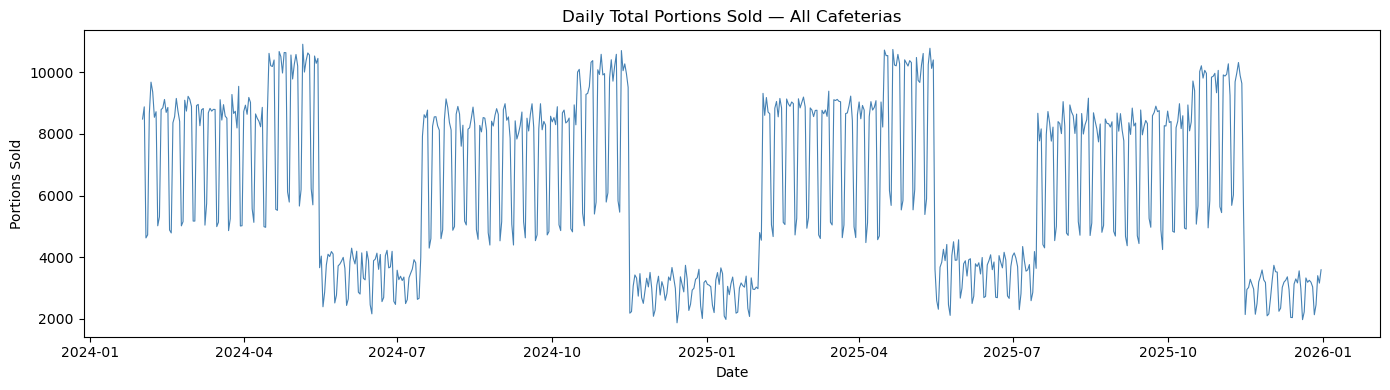

In [3]:
# --- Overall daily demand across all cafeterias ---
daily_demand = df.groupby('Date')['Portions_Sold'].sum().reset_index()
daily_demand.columns = ['ds', 'y']
daily_demand = daily_demand.sort_values('ds').reset_index(drop=True)

print('Daily demand shape:', daily_demand.shape)
print(daily_demand.head())

# plot raw demand
plt.figure(figsize=(14, 4))
plt.plot(daily_demand['ds'], daily_demand['y'], color='steelblue', linewidth=0.8)
plt.title('Daily Total Portions Sold — All Cafeterias')
plt.xlabel('Date')
plt.ylabel('Portions Sold')
plt.tight_layout()
plt.show()

## Step 4 — Train / Test Split

In [4]:
# use first 80% of dates for training, last 20% for testing
split_date = daily_demand['ds'].quantile(0.8)
split_date = pd.to_datetime(split_date)

train = daily_demand[daily_demand['ds'] <= split_date]
test  = daily_demand[daily_demand['ds'] >  split_date]

print('Train:', train.shape, '| from', train['ds'].min().date(), 'to', train['ds'].max().date())
print('Test :', test.shape,  '| from', test['ds'].min().date(),  'to', test['ds'].max().date())

Train: (560, 2) | from 2024-02-01 to 2025-08-13
Test : (140, 2) | from 2025-08-14 to 2025-12-31


## Step 5 — Train the Prophet Model

In [5]:
model = Prophet(
    yearly_seasonality  = True,   # picks up semester vs break patterns
    weekly_seasonality  = True,   # picks up weekday vs weekend patterns
    daily_seasonality   = False,  # not needed for daily data
    seasonality_mode    = 'multiplicative'  # demand scales up/down rather than shifting up/down
)

model.fit(train)
print('Model trained.')

01:51:53 - cmdstanpy - INFO - Chain [1] start processing
01:51:53 - cmdstanpy - INFO - Chain [1] done processing


Model trained.


## Step 6 — Forecast on Test Period

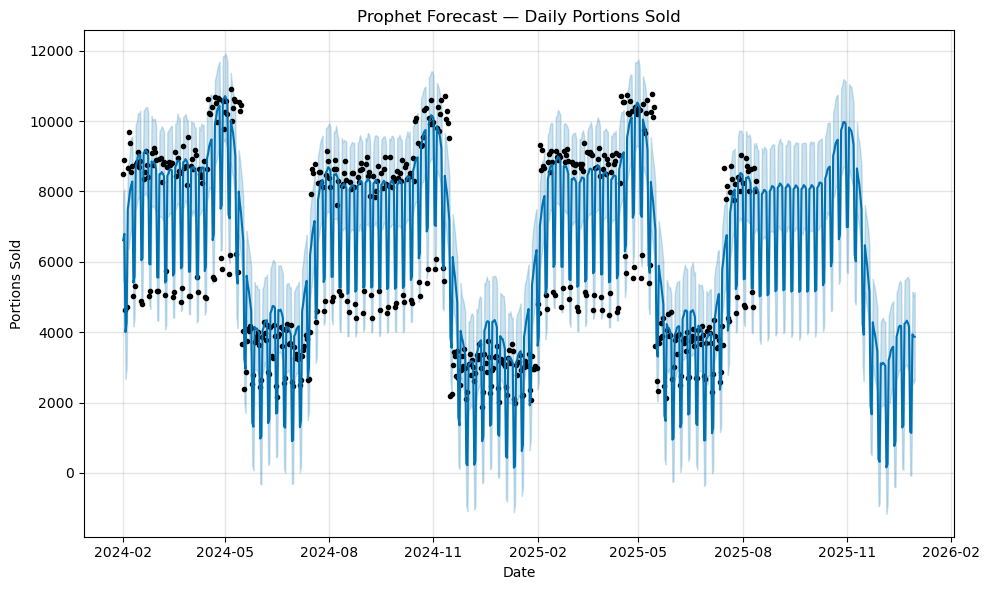

In [6]:
# create future dataframe covering the test period
future = model.make_future_dataframe(periods=len(test), freq='D')

forecast = model.predict(future)

# plot forecast vs actual
fig = model.plot(forecast)
plt.title('Prophet Forecast — Daily Portions Sold')
plt.xlabel('Date')
plt.ylabel('Portions Sold')
plt.tight_layout()
plt.show()

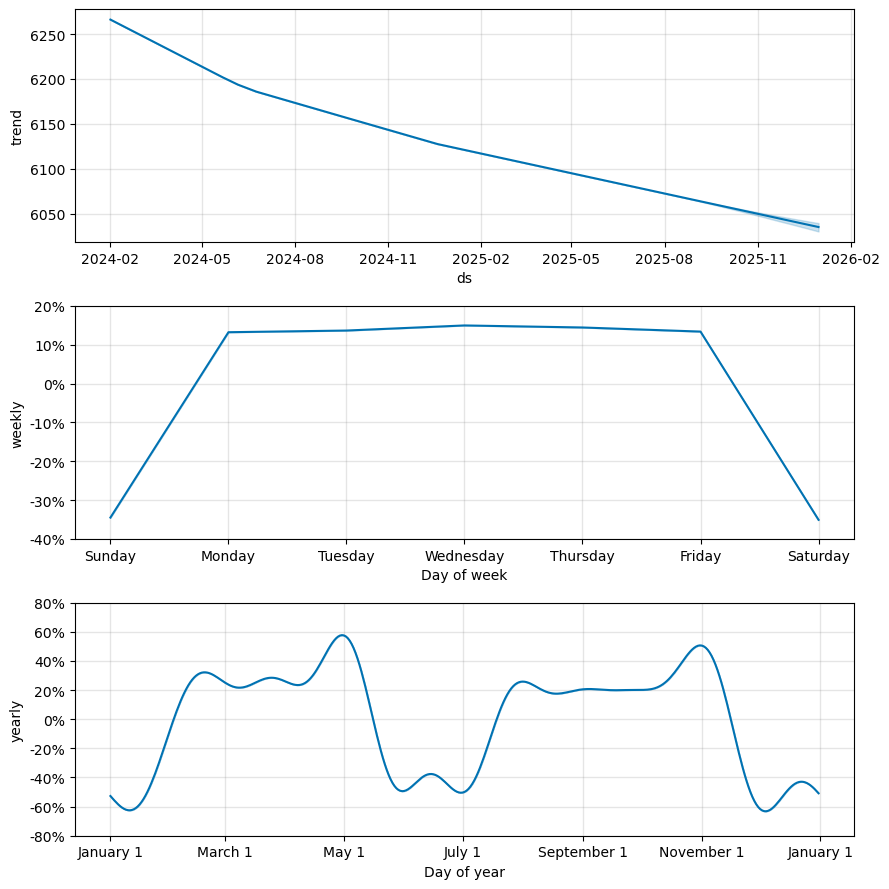

In [7]:
# plot the seasonal components Prophet learned
fig2 = model.plot_components(forecast)
plt.tight_layout()
plt.show()

## Step 7 — Evaluate the Model

In [8]:
# merge forecast with actual test values
forecast_test = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].merge(
    test, on='ds', how='inner'
)

mae  = mean_absolute_error(forecast_test['y'], forecast_test['yhat'])
rmse = np.sqrt(mean_squared_error(forecast_test['y'], forecast_test['yhat']))
mape = np.mean(np.abs((forecast_test['y'] - forecast_test['yhat']) / forecast_test['y'])) * 100

print('=== Forecast Evaluation ===')
print(f'MAE  (Mean Absolute Error)      : {mae:.2f} portions')
print(f'RMSE (Root Mean Squared Error)  : {rmse:.2f} portions')
print(f'MAPE (Mean Absolute % Error)    : {mape:.2f}%')

=== Forecast Evaluation ===
MAE  (Mean Absolute Error)      : 689.60 portions
RMSE (Root Mean Squared Error)  : 943.94 portions
MAPE (Mean Absolute % Error)    : 17.33%


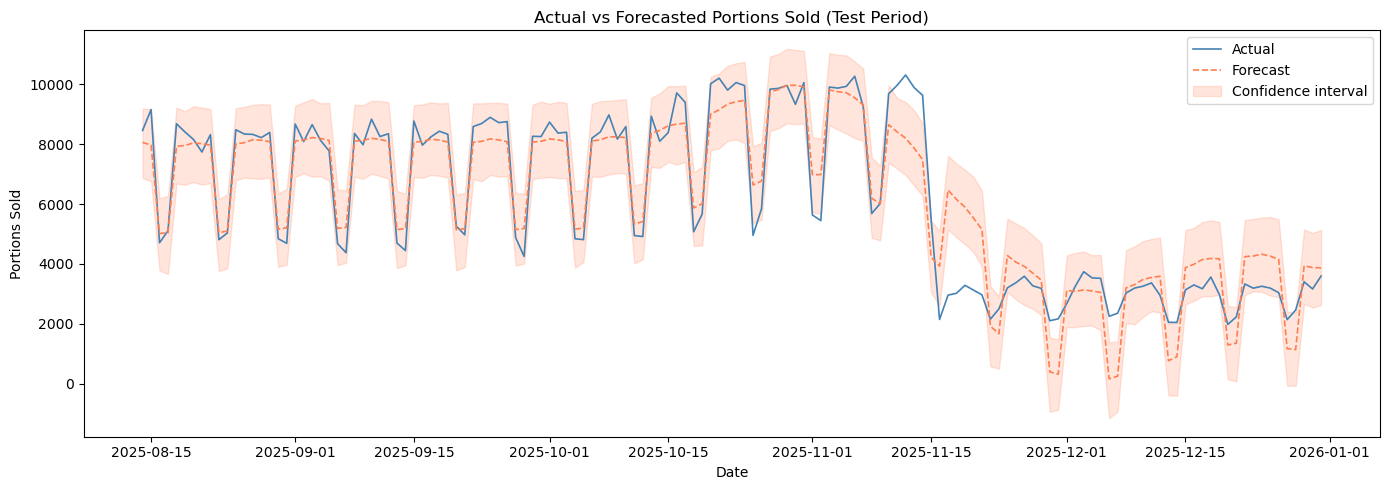

In [9]:
# plot actual vs predicted on test period
plt.figure(figsize=(14, 5))
plt.plot(forecast_test['ds'], forecast_test['y'],    color='steelblue', label='Actual',    linewidth=1.2)
plt.plot(forecast_test['ds'], forecast_test['yhat'], color='coral',     label='Forecast',  linewidth=1.2, linestyle='--')
plt.fill_between(forecast_test['ds'],
                 forecast_test['yhat_lower'],
                 forecast_test['yhat_upper'],
                 alpha=0.2, color='coral', label='Confidence interval')
plt.title('Actual vs Forecasted Portions Sold (Test Period)')
plt.xlabel('Date')
plt.ylabel('Portions Sold')
plt.legend()
plt.tight_layout()
plt.show()

## Step 8 — Forecast a Specific Cafeteria and Meal

Records for C01 - Posho & Beans: 700


01:00:01 - cmdstanpy - INFO - Chain [1] start processing
01:00:02 - cmdstanpy - INFO - Chain [1] done processing



=== C01 — Posho & Beans Forecast Evaluation ===
MAE  : 40.86 portions
MAPE : 54.24%


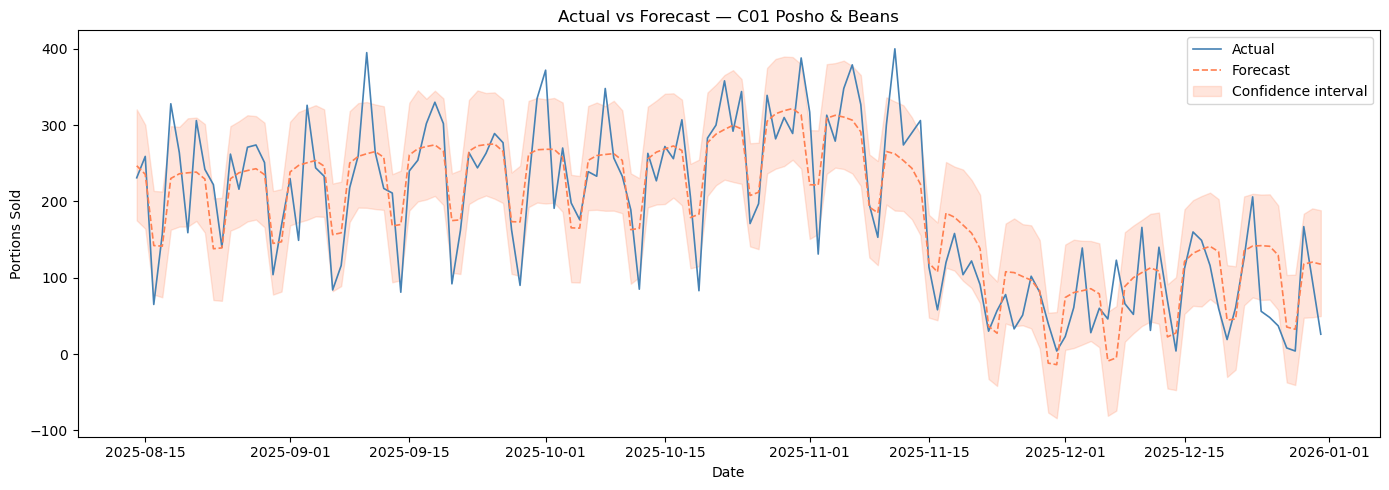

In [12]:
# change these to forecast any cafeteria and meal combination
CAFETERIA = 'C01'
MEAL      = 'Posho & Beans'

# filter to specific cafeteria and meal
subset = df[(df['Cafeteria_ID'] == CAFETERIA) & (df['Meal'] == MEAL)]
subset = subset.groupby('Date')['Portions_Sold'].sum().reset_index()
subset.columns = ['ds', 'y']
subset = subset.sort_values('ds').reset_index(drop=True)

print(f'Records for {CAFETERIA} - {MEAL}: {len(subset)}')

# train test split
split = subset['ds'].quantile(0.8)
split = pd.to_datetime(split)

train_s = subset[subset['ds'] <= split]
test_s  = subset[subset['ds'] >  split]

# train model
model_s = Prophet(
    yearly_seasonality = True,
    weekly_seasonality = True,
    daily_seasonality  = False,
    seasonality_mode   = 'multiplicative'
)
model_s.fit(train_s)

# forecast
future_s   = model_s.make_future_dataframe(periods=len(test_s), freq='D')
forecast_s = model_s.predict(future_s)

# evaluate
forecast_test_s = forecast_s[['ds','yhat','yhat_lower','yhat_upper']].merge(test_s, on='ds', how='inner')

mae_s  = mean_absolute_error(forecast_test_s['y'], forecast_test_s['yhat'])
mape_s = np.mean(np.abs((forecast_test_s['y'] - forecast_test_s['yhat']) / forecast_test_s['y'])) * 100

print(f'\n=== {CAFETERIA} — {MEAL} Forecast Evaluation ===')
print(f'MAE  : {mae_s:.2f} portions')
print(f'MAPE : {mape_s:.2f}%')

# plot
plt.figure(figsize=(14, 5))
plt.plot(forecast_test_s['ds'], forecast_test_s['y'],    color='steelblue', label='Actual',   linewidth=1.2)
plt.plot(forecast_test_s['ds'], forecast_test_s['yhat'], color='coral',     label='Forecast', linewidth=1.2, linestyle='--')
plt.fill_between(forecast_test_s['ds'],
                 forecast_test_s['yhat_lower'],
                 forecast_test_s['yhat_upper'],
                 alpha=0.2, color='coral', label='Confidence interval')
plt.title(f'Actual vs Forecast — {CAFETERIA} {MEAL}')
plt.xlabel('Date')
plt.ylabel('Portions Sold')
plt.legend()
plt.tight_layout()
plt.show()

## Step 9 — Forecast the Next 30 Days

01:52:27 - cmdstanpy - INFO - Chain [1] start processing
01:52:27 - cmdstanpy - INFO - Chain [1] done processing


=== 30-Day Demand Forecast ===
      Date  Forecast  Lower_Bound  Upper_Bound
2026-01-01    3559.0       2322.0       4739.0
2026-01-02    3426.0       2172.0       4623.0
2026-01-03     426.0       -768.0       1759.0
2026-01-04     374.0       -786.0       1531.0
2026-01-05    3182.0       1984.0       4393.0
2026-01-06    3142.0       1869.0       4325.0
2026-01-07    3214.0       1976.0       4423.0
2026-01-08    3147.0       1896.0       4391.0
2026-01-09    3078.0       1837.0       4295.0
2026-01-10     151.0      -1102.0       1377.0
2026-01-11     181.0      -1070.0       1434.0
2026-01-12    3077.0       1838.0       4282.0
2026-01-13    3132.0       1912.0       4398.0
2026-01-14    3304.0       1960.0       4527.0
2026-01-15    3343.0       2091.0       4627.0
2026-01-16    3380.0       2129.0       4625.0
2026-01-17     564.0       -611.0       1784.0
2026-01-18     703.0       -544.0       1886.0
2026-01-19    3707.0       2430.0       4794.0
2026-01-20    3869.0       26

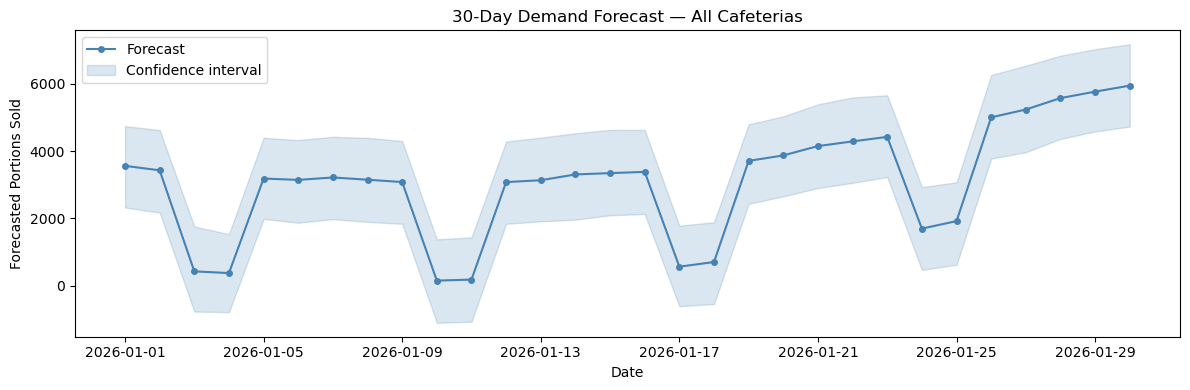

In [11]:
# retrain on full dataset then forecast 30 days ahead
model_full = Prophet(
    yearly_seasonality = True,
    weekly_seasonality = True,
    daily_seasonality  = False,
    seasonality_mode   = 'multiplicative'
)
model_full.fit(daily_demand)

future_30   = model_full.make_future_dataframe(periods=30, freq='D')
forecast_30 = model_full.predict(future_30)

# show only the next 30 days
next_30 = forecast_30[forecast_30['ds'] > daily_demand['ds'].max()][
    ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
].round(0)

next_30.columns = ['Date', 'Forecast', 'Lower_Bound', 'Upper_Bound']
print('=== 30-Day Demand Forecast ===')
print(next_30.to_string(index=False))

# plot
plt.figure(figsize=(12, 4))
plt.plot(next_30['Date'], next_30['Forecast'], color='steelblue', marker='o', markersize=4, label='Forecast')
plt.fill_between(next_30['Date'],
                 next_30['Lower_Bound'],
                 next_30['Upper_Bound'],
                 alpha=0.2, color='steelblue', label='Confidence interval')
plt.title('30-Day Demand Forecast — All Cafeterias')
plt.xlabel('Date')
plt.ylabel('Forecasted Portions Sold')
plt.legend()
plt.tight_layout()
plt.show()